In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
multi = gpd.read_file("datos/lineamientos_sombreado_multidireccional.shp")
comb1 = gpd.read_file("datos/lineamientos_combinado_1.shp")
comb2 = gpd.read_file("datos/lineamientos_combiando2.shp")
rrim  = gpd.read_file("datos/LINEAMIENTOS_RRMI.shp")

In [15]:
def calcular_azimut(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    angulo = np.degrees(np.arctan2(x2 - x1, y2 - y1))
    return angulo % 180

for nombre, capa in [("Multidireccional", multi),
                     ("Combinado1",       comb1),
                     ("Combinado2",       comb2),
                     ("RRIM",             rrim)]:
    capa["azimut"]     = capa.geometry.apply(calcular_azimut)
    capa["longitud_m"] = capa.geometry.length

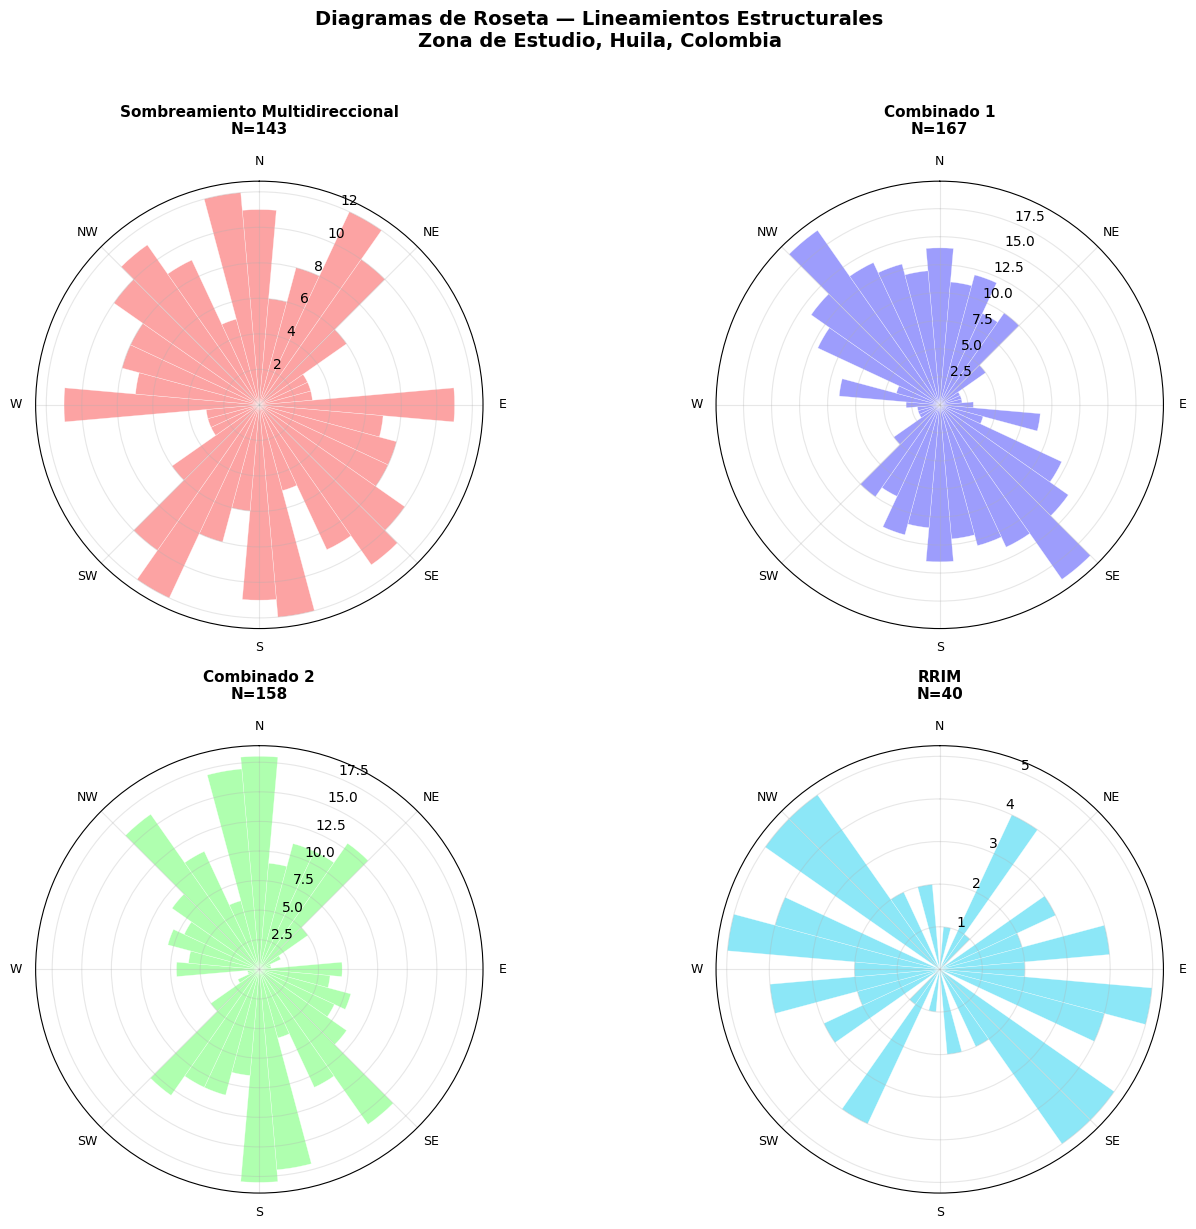

In [16]:
fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(14, 12))
fig.patch.set_facecolor("white")

capas = [
    ("Sombreamiento Multidireccional", multi,  "#FC7C7C", 143),
    ("Combinado 1",                    comb1,  "#7474FB", 167),
    ("Combinado 2",                    comb2,  "#8EFF8E", 158),
    ("RRIM",                           rrim,   "#5BDDF4",  40),
]

bins_full = np.deg2rad(np.arange(0, 361, 10))

for ax, (nombre, capa, color, n) in zip(axes.flat, capas):
    azimutas = np.concatenate([capa["azimut"].values,
                                capa["azimut"].values + 180])
    theta = np.deg2rad(azimutas)
    frec, _ = np.histogram(theta, bins=bins_full)
    ax.bar(bins_full[:-1], frec, width=np.deg2rad(10),
           color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"{nombre}\nN={n}", pad=15, fontsize=11, fontweight="bold")
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Diagramas de Roseta — Lineamientos Estructurales\nZona de Estudio, Huila, Colombia",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figuras/rosetas_frecuencia.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

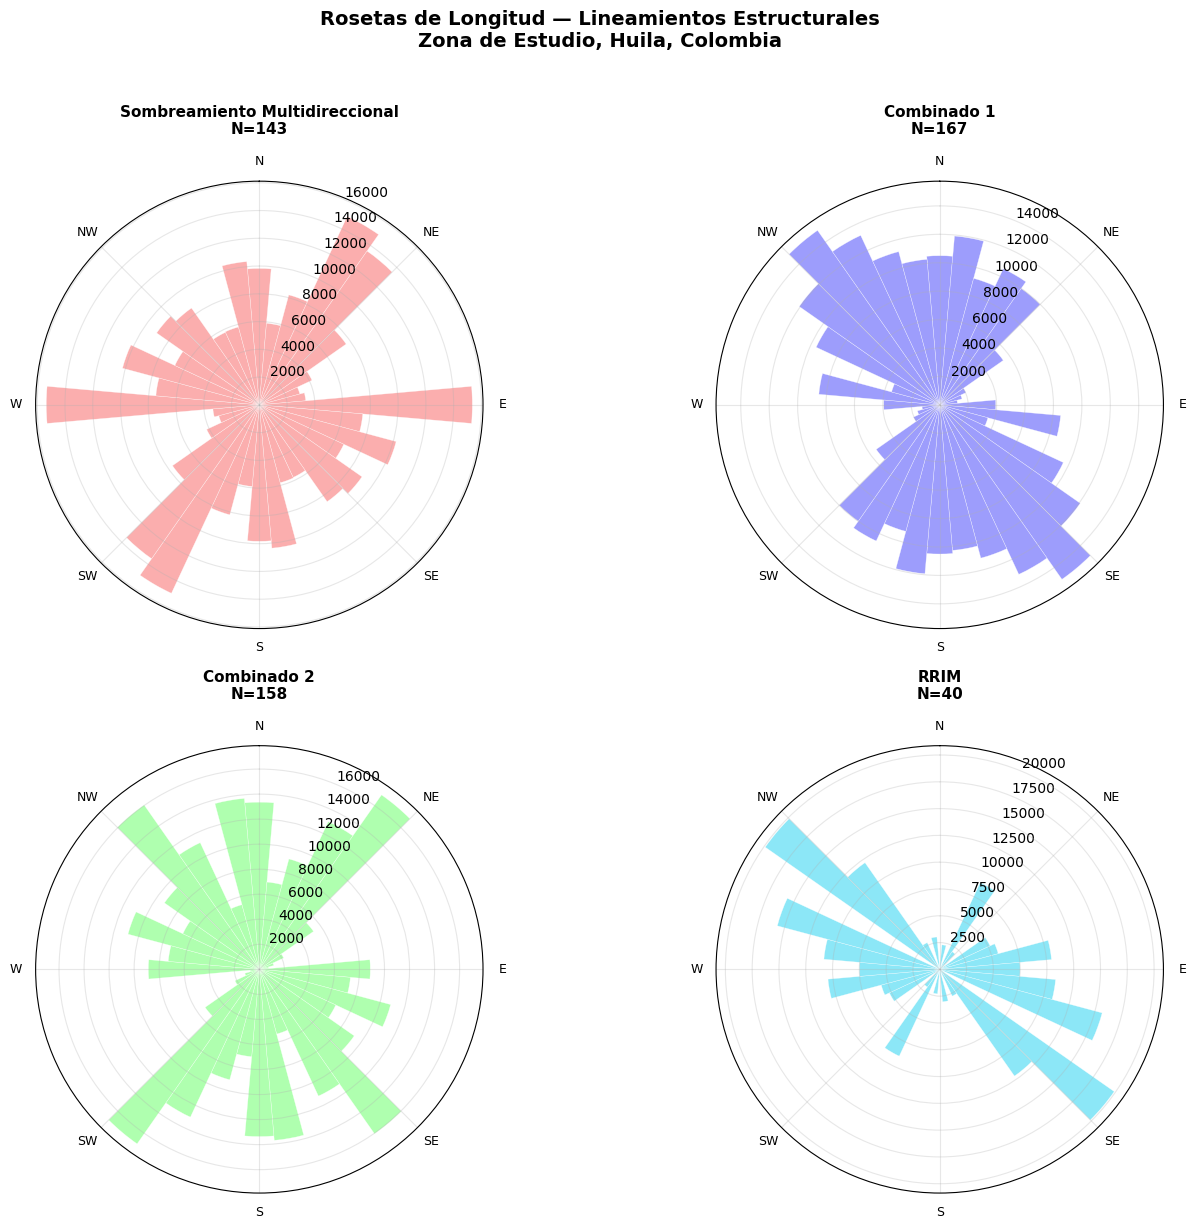

In [17]:
fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(14, 12))
fig.patch.set_facecolor("white")

capas = [
    ("Sombreamiento Multidireccional", multi,  "#FA8C8C", 143),
    ("Combinado 1",                    comb1,  "#7474FB", 167),
    ("Combinado 2",                    comb2,  "#8EFF8E", 158),
    ("RRIM",                           rrim,   "#5BDDF4",  40),
]

bins_full = np.deg2rad(np.arange(0, 361, 10))

for ax, (nombre, capa, color, n) in zip(axes.flat, capas):
    azimutas   = np.concatenate([capa["azimut"].values, capa["azimut"].values + 180])
    longitudes = np.concatenate([capa["longitud_m"].values, capa["longitud_m"].values])
    theta      = np.deg2rad(azimutas)
    long_hist, _ = np.histogram(theta, bins=bins_full, weights=longitudes)
    ax.bar(bins_full[:-1], long_hist, width=np.deg2rad(10),
           color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"{nombre}\nN={n}", pad=15, fontsize=11, fontweight="bold")
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Rosetas de Longitud — Lineamientos Estructurales\nZona de Estudio, Huila, Colombia",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figuras/rosetas_longitud.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [19]:
def azimut_dominante(azimutas):
    bins = np.arange(0, 181, 10)
    counts, edges = np.histogram(azimutas, bins=bins)
    idx = np.argmax(counts)
    return round((edges[idx] + edges[idx+1]) / 2, 0)

resumen = []

for nombre, capa in [("Multidireccional", multi),
                     ("Combinado 1",      comb1),
                     ("Combinado 2",      comb2),
                     ("RRIM",             rrim)]:
    resumen.append({
        "Técnica":               nombre,
        "N lineamientos":        len(capa),
        "Longitud total (km)":   round(capa["longitud_m"].sum()/1000, 1),
        "Longitud promedio (m)": round(capa["longitud_m"].mean(), 0),
        "Longitud máxima (m)":   round(capa["longitud_m"].max(), 0),
        "Azimut promedio (°)":   round(capa["azimut"].mean(), 1),
        "Azimut dominante (°)":  azimut_dominante(capa["azimut"].values),
    })

df_resumen = pd.DataFrame(resumen)
df_resumen.to_csv("datos/estadisticas_lineamientos.csv", index=False)
df_resumen

,Técnica,N lineamientos,Longitud total (km),Longitud promedio (m),Longitud máxima (m),Azimut promedio (°),Azimut dominante (°)
0,Multidireccional,143,149.9,1048.0,3171.0,91.8,35.0
1,Combinado 1,167,149.8,897.0,2612.0,97.5,145.0
2,Combinado 2,158,158.2,1001.0,3242.0,90.7,5.0
3,RRIM,40,106.4,2660.0,7212.0,103.2,105.0


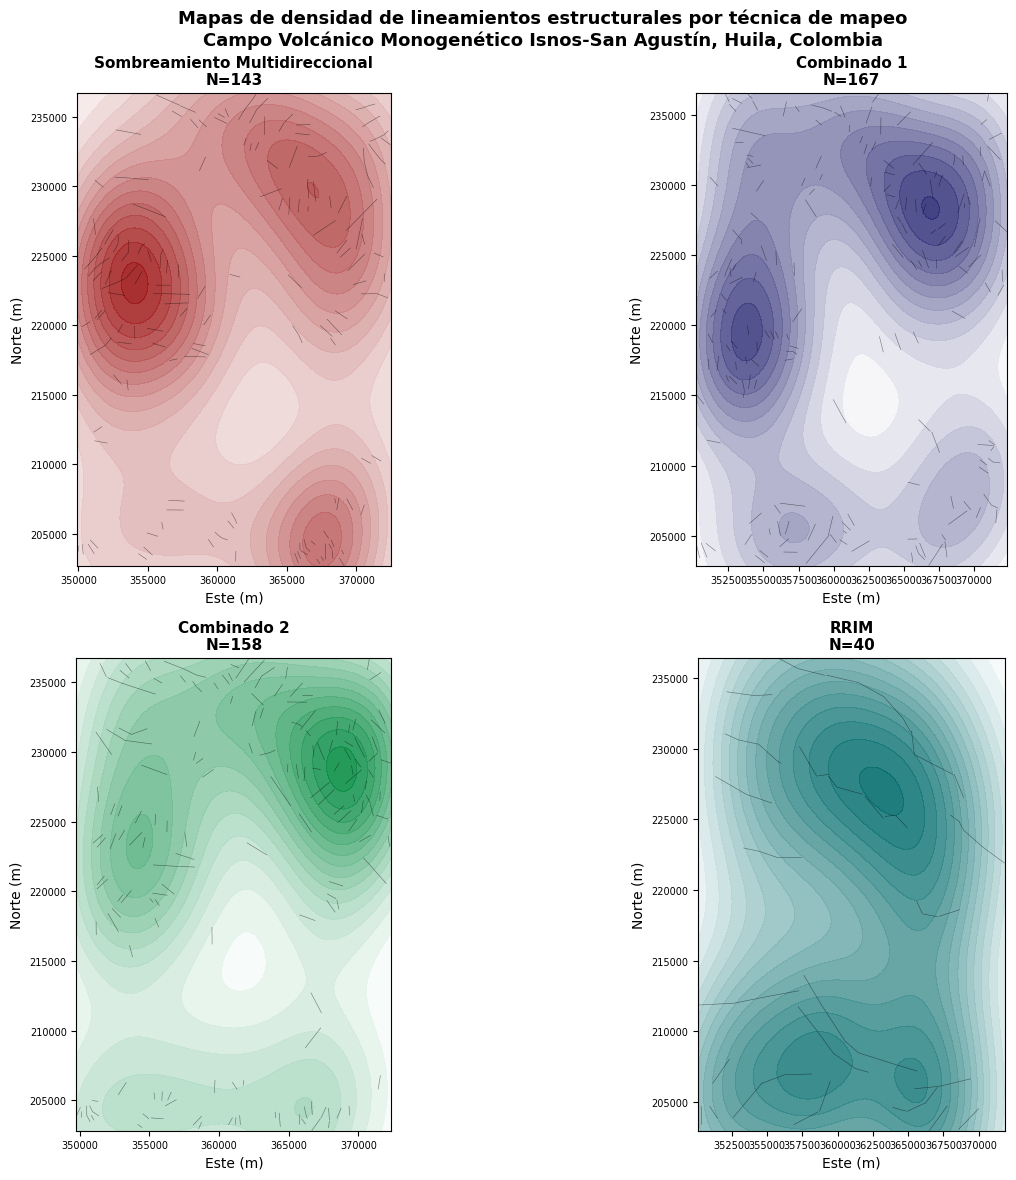

In [26]:
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

capas = [
    ("Sombreamiento Multidireccional", multi,  "#9D1212"),
    ("Combinado 1",                    comb1,  "#262672"),
    ("Combinado 2",                    comb2,  "#058C42"),
    ("RRIM",                           rrim,   "#006B6B"),
]

for ax, (nombre, capa, color) in zip(axes.flat, capas):
    cx = capa.geometry.centroid.x.values
    cy = capa.geometry.centroid.y.values
    xy  = np.vstack([cx, cy])
    kde = gaussian_kde(xy)
    xmin, ymin, xmax, ymax = capa.total_bounds
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    cmap = LinearSegmentedColormap.from_list("", ["white", color])
    ax.contourf(xx, yy, zz, levels=15, alpha=0.9, cmap=cmap)
    capa.plot(ax=ax, color="black", linewidth=0.4, alpha=0.5)
    ax.set_title(f"{nombre}\nN={len(capa)}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Este (m)")
    ax.set_ylabel("Norte (m)")
    ax.tick_params(labelsize=7)

plt.suptitle("Mapas de densidad de lineamientos estructurales por técnica de mapeo\nCampo Volcánico Monogenético Isnos-San Agustín, Huila, Colombia",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figuras/densidad_lineamientos.png", dpi=300, bbox_inches="tight")
plt.show()

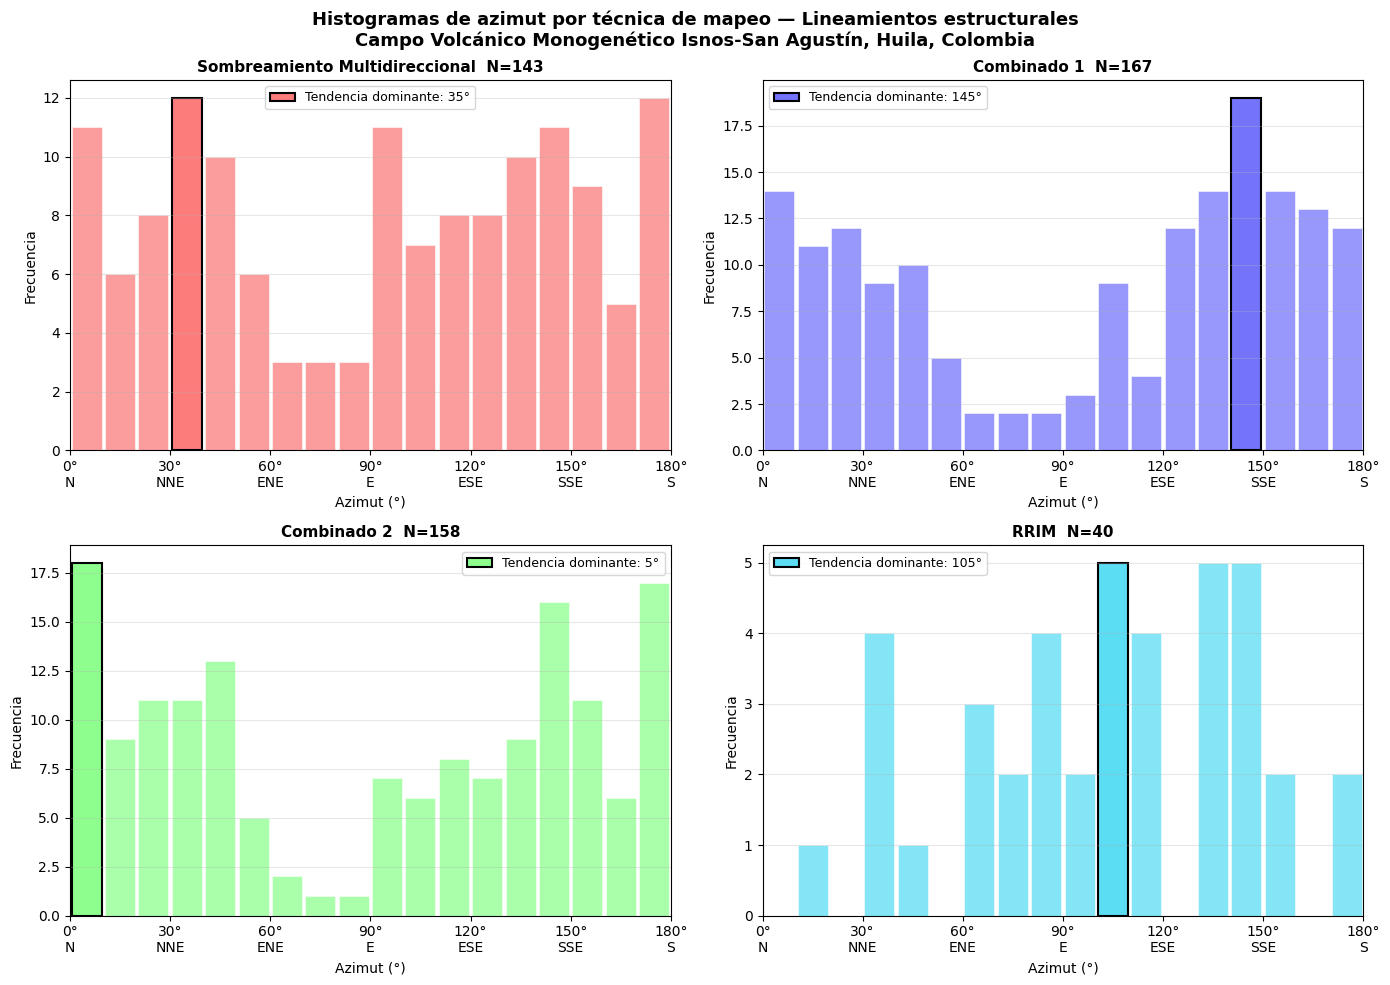

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("white")

capas = [
    ("Sombreamiento Multidireccional", multi,  "#FC7C7C", 143),
    ("Combinado 1",                    comb1,  "#7474FB", 167),
    ("Combinado 2",                    comb2,  "#8EFF8E", 158),
    ("RRIM",                           rrim,   "#5BDDF4",  40),
]

bins = np.arange(0, 181, 10)

for ax, (nombre, capa, color, n) in zip(axes.flat, capas):
    azimutas = capa["azimut"].values
    counts, edges = np.histogram(azimutas, bins=bins)
    centros = (edges[:-1] + edges[1:]) / 2
    ax.bar(centros, counts, width=9, color=color,
           alpha=0.75, edgecolor="white", linewidth=0.5)
    idx_max = np.argmax(counts)
    ax.bar(centros[idx_max], counts[idx_max], width=9,
           color=color, alpha=1.0, edgecolor="black", linewidth=1.5,
           label=f"Tendencia dominante: {centros[idx_max]:.0f}°")
    ax.set_xlabel("Azimut (°)", fontsize=10)
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.set_title(f"{nombre}  N={n}", fontsize=11, fontweight="bold")
    ax.set_xticks([0, 30, 60, 90, 120, 150, 180])
    ax.set_xticklabels(["0°\nN", "30°\nNNE", "60°\nENE",
                         "90°\nE", "120°\nESE", "150°\nSSE", "180°\nS"])
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlim(0, 180)

plt.suptitle("Histogramas de azimut por técnica de mapeo — Lineamientos estructurales\nCampo Volcánico Monogenético Isnos-San Agustín, Huila, Colombia",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figuras/histogramas_lineamientos.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()